# Validation temporelle de l'apport de la prévision météo (§V-B de l'article)

**Contexte.** Dans l'article soumis à AKTIION 2026, l'apport de la prévision numérique (Open-Meteo
*Previous Runs*) est mesuré par une **validation croisée mélangée** (`StratifiedKFold(shuffle=True)`,
`build_prevruns_experiment.py`) : AUC 0,888 → **0,913**, PR-AUC 0,657 → **0,732**, et le modèle
appris battrait la prévision brute (0,912 vs 0,874). Ce protocole mélange des jours voisins et les
18 zones d'une même date entre entraînement et test.

**Ce notebook** ré-évalue la question avec des protocoles temporels, sur une période **étendue**.

| | Version précédente | Cette version |
|---|---|---|
| Période de test | 2024-06 → 2025-07 (2025 = juin–juillet seulement) | **2024-06 → 2026-09** : 3 saisons, dont 2025 complète |
| Prévisions | fichiers d'origine (6 zones à coordonnées « ville ») | cellules exactes de la réanalyse (`fetch_previous_runs.py` corrigé) |
| Baselines | prévision brute (cumul) | + **règle d'alerte appliquée à la prévision**, **climatologie**, **persistance** |
| Variables de prévision | brutes (mm) | + **normalisées par les seuils de chaque zone** |
| Seuil opérationnel | choisi sur le test (oracle) | **choisi sur le passé uniquement** |
| Étude de cas | — | inondation de **Tambacounda, 14 août 2025** (SitRep OCHA) |

Protocoles : **A** CV mélangée (reproduction de l'article, période d'origine) ;
**B** blocs temporels purgés ; **C** forward-chaining (strictement causal, protocole principal) ;
**D** holdouts par saison ; **E** modèle réanalyse appris sur 2005–2023 + couche légère avec la prévision.

In [1]:
import sys, warnings
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
warnings.filterwarnings("ignore")

ROOT = Path.cwd()
sys.path.insert(0, str(ROOT))
import rf_forecast as base
import fetch_extension

from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score, average_precision_score, precision_recall_curve

H = 3                     # horizon t+1…t+3
PURGE_BEFORE = H          # jours retirés avant un bloc test (leur cible chevauche le bloc)
EMBARGO_AFTER = 15        # (protocole B) jours retirés après : precip_15d_sum contient la pluie du bloc
SEED = 42
EXT_START, EXT_END = "2025-08-01", "2026-09-18"
OUT = ROOT / "rf_forecast_results" / "validation_temporelle"
OUT.mkdir(parents=True, exist_ok=True)

## 1. Données

Réanalyse 2005-04 → 2025-07 (fichiers de l'article) **+ extension 2025-08 → 2026-09** aux mêmes
cellules (`fetch_extension.py`, téléchargée une fois puis mise en cache). Seuils P97/P95 calés sur
< 2023, comme dans l'article.

In [2]:
if not (ROOT / "donnees_extension").exists() or not (ROOT / "donnees_previous_runs_ext").exists():
    fetch_extension.main(EXT_START, EXT_END)

def load_extension(folder):
    frames = []
    for csv in sorted(folder.glob("*.csv")):
        meta = pd.read_csv(csv, nrows=1).iloc[0].to_dict()
        meta = {base.normalise_column(k): v for k, v in meta.items()}
        f = pd.read_csv(csv, skiprows=3)
        f.columns = [base.normalise_column(c) for c in f.columns]
        f["time"] = pd.to_datetime(f["time"], errors="coerce")
        f = f.dropna(subset=["time"])
        num = [c for c in f.columns if c != "time"]
        f[num] = f[num].apply(pd.to_numeric, errors="coerce")
        f["location"] = base.location_from_path(csv)
        for g in ("latitude", "longitude", "elevation"):
            f[g] = base.coerce_float(meta.get(g))
        frames.append(f)
    return pd.concat(frames, ignore_index=True)

hourly_old = base.load_hourly(base.DATA_DIR)
hourly_ext = load_extension(ROOT / "donnees_extension")
assert hourly_ext.time.min() > hourly_old.time.max(), "chevauchement inattendu"
hourly = pd.concat([hourly_old, hourly_ext], ignore_index=True).sort_values(["location", "time"])
print("réanalyse :", hourly.time.min(), "→", hourly.time.max(), "|", hourly.location.nunique(), "zones")

daily = base.add_features(base.aggregate_daily(hourly))
TH = base.calibrate_thresholds(daily[daily.date < base.SPLIT_DATE], H)      # seuils calés < 2023
daily = base.add_future_target(daily, H, TH)
base.assert_no_leakage(base.SELECTED_FEATURES)

réanalyse : 2005-04-07 00:00:00 → 2026-09-18 23:00:00 | 18 zones


✓ Anti-fuite : aucune feature ne provient de la fenêtre-cible.


**Contrôle de raccord** au 31/07/2025 → 01/08/2025 : les deux téléchargements doivent se
prolonger sans saut (même produit, même cellule). On compare le saut à la variation journalière
habituelle de chaque variable.

In [3]:
seam = daily[daily.date.isin(pd.to_datetime(["2025-07-30", "2025-07-31", "2025-08-01", "2025-08-02"]))]
chk = []
for v in ["soil_moisture_0_to_7cm_m3_per_m3_mean", "soil_moisture_100_to_255cm_m3_per_m3_mean",
          "temperature_2m_degc_mean", "pressure_msl_hpa_mean"]:
    typical = daily.groupby("location")[v].diff().abs().median()
    jump = (seam.pivot(index="date", columns="location", values=v).diff().abs()
            .loc[pd.Timestamp("2025-08-01")].median())
    chk.append(dict(variable=v, saut_median_au_raccord=jump, variation_journalière_médiane=typical))
pd.DataFrame(chk).round(4)

,variable,saut_median_au_raccord,variation_journalière_médiane
0,soil_moisture_0_to_7cm_m3_per_m3_mean,0.0065,0.0012
1,soil_moisture_100_to_255cm_m3_per_m3_mean,0.0000,0.0000
2,temperature_2m_degc_mean,0.9458,0.6125
3,pressure_msl_hpa_mean,0.2000,0.6542


In [4]:
# Prévisions : 2024-01 → 2025-07 (cellules exactes, identiques à fetch_previous_runs.py corrigé)
#             + 2025-08 → 2026-09 (extension)
def read_pr(folder):
    fr = []
    for c in sorted(folder.glob("*_prevruns.csv")):
        f = pd.read_csv(c, parse_dates=["date"])
        f["location"] = c.stem.replace("_prevruns", "")
        fr.append(f[["date", "actual", "fc_lead1", "fc_lead2", "fc_lead3", "location"]])
    return pd.concat(fr, ignore_index=True)

pr = pd.concat([read_pr(ROOT / "donnees_previous_runs_v2"), read_pr(ROOT / "donnees_previous_runs_ext")])
assert not pr.duplicated(["location", "date"]).any()

# contrôle : la pluie « réalisée » des fichiers de prévision = la réanalyse de la même zone
chk = pr.merge(daily[["location", "date", "precipitation_mm_sum"]], on=["location", "date"])
print("corr(pluie réalisée prévisions, réanalyse) par zone : min =",
      round(chk.groupby("location").apply(lambda g: g.actual.corr(g.precipitation_mm_sum)).min(), 4))

out = []
for loc, g in pr.groupby("location", group_keys=False):
    g = g.sort_values("date").copy()
    g["fc_next1"] = g["fc_lead1"].shift(-1)      # prévu pour t+1, émis à t
    g["fc_next2"] = g["fc_lead2"].shift(-2)      # prévu pour t+2, émis à t
    g["fc_next3"] = g["fc_lead3"].shift(-3)      # prévu pour t+3, émis à t
    g["fc_sum_next3"] = g[["fc_next1", "fc_next2", "fc_next3"]].sum(axis=1, min_count=3)
    g["fc_max_next3"] = g[["fc_next1", "fc_next2", "fc_next3"]].max(axis=1)
    out.append(g)
pr = pd.concat(out, ignore_index=True)
# contrôle de fuite : la prévision de t+1 émise à t doit différer de la pluie réalisée en t+1
chk = pr.merge(daily[["location", "date", "precipitation_mm_sum"]].assign(date=lambda d: d.date - pd.Timedelta(days=1)),
               on=["location", "date"])
print(f"skill J+1 : corr(prévu, réalisé) = {chk.fc_next1.corr(chk.precipitation_mm_sum):.3f}  (< 1 → vraie prévision)")

corr(pluie réalisée prévisions, réanalyse) par zone : min = 1.0


skill J+1 : corr(prévu, réalisé) = 0.563  (< 1 → vraie prévision)


In [5]:
FC = ["fc_next1", "fc_sum_next3", "fc_max_next3"]
REA = base.SELECTED_FEATURES
P97 = {z: a for z, (a, b) in TH.items()}; P95 = {z: b for z, (a, b) in TH.items()}

df = daily.merge(pr[["location", "date"] + FC], on=["location", "date"], how="inner")
# prévision exprimée en « fraction du seuil d'alerte de la zone » (seuils calés < 2023 : pas de fuite)
df["fcn_max"] = df.fc_max_next3 / df.location.map(P97)
df["fcn_sum"] = df.fc_sum_next3 / df.location.map(P95)
FCN = ["fcn_max", "fcn_sum"]

rows = df[(df.month.isin(base.RAINY_MONTHS)) & (df.date >= pd.Timestamp("2024-06-01"))].copy()
rows = rows.dropna(subset=REA + FC + ["flood_risk"]).sort_values(["date", "location"]).reset_index(drop=True)
rows["flood_risk"] = rows["flood_risk"].astype(int)
rows["season"] = rows.date.dt.year
assert rows.location.nunique() == 18
print(f"{len(rows)} jours-zones, {rows.location.nunique()} zones, {rows.flood_risk.mean()*100:.1f}% à risque, "
      f"{rows.date.min().date()} → {rows.date.max().date()}")
rows.groupby("season").flood_risk.agg(jours_zones="size", positifs="sum", taux="mean").round(3)

8514 jours-zones, 18 zones, 21.0% à risque, 2024-06-01 → 2026-09-15


,jours_zones,positifs,taux
season,,,
2024,3294,722,0.219
2025,3294,740,0.225
2026,1926,322,0.167


## 2. Baselines sans apprentissage

- **Règle d'alerte sur la prévision** : on applique à la prévision la définition même de la cible,
  `max(pluie max prévue / P97, cumul prévu / P95)` de la zone. C'est la baseline opérationnelle
  naturelle (« alerter quand la prévision dépasse le seuil »).
- **Prévision brute (cumul)** : cumul prévu t+1…t+3 en mm (baseline de l'article).
- **Climatologie** : fréquence historique (2005–2023) de la cible pour la zone et la période de
  l'année (± 15 jours). Mesure ce qu'on gagne à connaître la saison.
- **Persistance** : cumul des 3 derniers jours / P95 (version continue de la baseline de l'article).

In [6]:
hist = daily[(daily.month.isin(base.RAINY_MONTHS)) & (daily.date < pd.Timestamp("2024-01-01"))]
hist = hist.dropna(subset=REA + ["flood_risk"]).copy()
hist["flood_risk"] = hist.flood_risk.astype(int)

# climatologie : moyenne circulaire ± 15 jours du taux de cible, par zone et jour de l'année
hist["doy"] = hist.date.dt.dayofyear
clim = {}
for z, g in hist.groupby("location"):
    s = g.groupby("doy").flood_risk.agg(["sum", "count"]).reindex(range(1, 367), fill_value=0)
    k = np.ones(31)
    num = np.convolve(np.r_[s["sum"].values[-15:], s["sum"].values, s["sum"].values[:15]], k, "valid")
    den = np.convolve(np.r_[s["count"].values[-15:], s["count"].values, s["count"].values[:15]], k, "valid")
    clim[z] = pd.Series(num / np.maximum(den, 1), index=range(1, 367))
rows["doy"] = rows.date.dt.dayofyear

BASELINES = {
    "Règle d'alerte sur la prévision": np.maximum(rows.fcn_max, rows.fcn_sum),
    "Prévision brute (cumul, mm)": rows.fc_sum_next3,
    "Climatologie": pd.Series([clim[z][d] for z, d in zip(rows.location, rows.doy)], index=rows.index),
    "Persistance": rows.precip_3d_sum / rows.location.map(P95),
}
RULE = "Règle d'alerte sur la prévision"
pd.DataFrame({k: [roc_auc_score(rows.flood_risk, v), average_precision_score(rows.flood_risk, v)]
              for k, v in BASELINES.items()}, index=["AUC (toute la période)", "PR-AUC"]).T.round(3)

,AUC (toute la période),PR-AUC
Règle d'alerte sur la prévision,0.848,0.556
"Prévision brute (cumul, mm)",0.844,0.547
Climatologie,0.767,0.369
Persistance,0.723,0.354


## 3. Modèles appris (même Random Forest que l'article)

In [7]:
FEATURE_SETS = {
    "Réanalyse seule": REA,
    "Prévision seule": FC,
    "Réanalyse + Prévision": REA + FC,
    "Réanalyse + Prévision normalisée": REA + FC + FCN,
}

def rf():
    return make_pipeline(StandardScaler(), RandomForestClassifier(
        n_estimators=400, max_depth=10, min_samples_leaf=10, max_features="sqrt",
        class_weight="balanced_subsample", random_state=SEED, n_jobs=-1))

def fit_predict(feats, tr, te):
    m = rf().fit(tr[feats].to_numpy(float), tr.flood_risk.to_numpy(int))
    return m.predict_proba(te[feats].to_numpy(float))[:, 1]

def scores(y, p):
    return dict(AUC=roc_auc_score(y, p), PR_AUC=average_precision_score(y, p))

## 4. Expérience A — protocole de l'article (CV mélangée), période d'origine

Reproduction sur 2024-06 → 2025-07, puis mesure de ce que l'entraînement « voit » du test.

In [8]:
art = rows[rows.date <= pd.Timestamp("2025-07-31")].reset_index(drop=True)
y_art = art.flood_risk.to_numpy(int)
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
resA, same_date = [], []
for name, feats in list(FEATURE_SETS.items())[:3]:
    X = art[feats].to_numpy(float); au, ap = [], []
    for tr, te in skf.split(X, y_art):
        p = rf().fit(X[tr], y_art[tr]).predict_proba(X[te])[:, 1]
        au.append(roc_auc_score(y_art[te], p)); ap.append(average_precision_score(y_art[te], p))
        if name == "Réanalyse seule":
            same_date.append(art.date.iloc[te].isin(set(art.date.iloc[tr])).mean())
    resA.append(dict(Protocole="A. CV mélangée (article)", Modèle=name, AUC=np.mean(au), PR_AUC=np.mean(ap)))
resA.append(dict(Protocole="A. CV mélangée (article)", Modèle="Prévision brute (cumul, mm)",
                 **scores(y_art, art.fc_sum_next3)))
resA = pd.DataFrame(resA)
print(f"{len(art)} jours-zones ; part des lignes test dont la même date est dans le train : {np.mean(same_date)*100:.0f} %")
resA.round(3)

4392 jours-zones ; part des lignes test dont la même date est dans le train : 100 %


,Protocole,Modèle,AUC,PR_AUC
0,A. CV mélangée (article),Réanalyse seule,0.890,0.657
1,A. CV mélangée (article),Prévision seule,0.869,0.591
2,A. CV mélangée (article),Réanalyse + Prévision,0.914,0.727
3,A. CV mélangée (article),"Prévision brute (cumul, mm)",0.876,0.599


## 5. Blocs temporels

Chaque saison est découpée en blocs d'environ un mois (juin–juillet, août, septembre,
octobre–novembre). 2026 s'arrête mi-septembre.

In [9]:
def block_of(d):
    m = d.month
    part = "1 juin-juil" if m in (6, 7) else "2 août" if m == 8 else "3 sept" if m == 9 else "4 oct-nov"
    return f"{d.year}-{part}"
rows["block"] = rows.date.map(block_of)
ORDER = sorted(rows.block.unique())
rows.groupby("block").agg(debut=("date", "min"), fin=("date", "max"), n=("flood_risk", "size"),
                          positifs=("flood_risk", "sum"), taux=("flood_risk", "mean")).round(3)

,debut,fin,n,positifs,taux
block,,,,,
2024-1 juin-juil,2024-06-01,2024-07-31,1098,181,0.165
2024-2 août,2024-08-01,2024-08-31,558,215,0.385
2024-3 sept,2024-09-01,2024-09-30,540,258,0.478
2024-4 oct-nov,2024-10-01,2024-11-30,1098,68,0.062
2025-1 juin-juil,2025-06-01,2025-07-31,1098,136,0.124
2025-2 août,2025-08-01,2025-08-31,558,309,0.554
2025-3 sept,2025-09-01,2025-09-30,540,273,0.506
2025-4 oct-nov,2025-10-01,2025-11-30,1098,22,0.020
2026-1 juin-juil,2026-06-01,2026-07-31,1098,116,0.106


## 6. Expérience C — forward-chaining (protocole principal, strictement causal)

Pour chaque bloc k : entraînement sur **tous les blocs antérieurs** (moins les 3 derniers jours,
dont la cible chevauche le bloc k), test sur le bloc k. Le premier bloc sert seulement à
l'entraînement.

On y ajoute l'**expérience E** : un Random Forest réanalyse entraîné **une seule fois sur
2005–2023** (`p_hist`), puis une régression logistique légère combinant `logit(p_hist)` et la
prévision, ré-entraînée en forward-chaining. Peu de paramètres à apprendre sur la courte archive de
prévisions.

In [10]:
m_hist = rf().fit(hist[REA].to_numpy(float), hist.flood_risk.to_numpy(int))
rows["p_hist"] = m_hist.predict_proba(rows[REA].to_numpy(float))[:, 1]
rows["logit_hist"] = np.log((rows.p_hist + 1e-4) / (1 - rows.p_hist + 1e-4))
print(f"modèle historique : {len(hist)} jours-zones (2005–2023)")
STACK = ["logit_hist"] + FC + FCN
def stacker():
    return make_pipeline(StandardScaler(), LogisticRegression(max_iter=2000, class_weight="balanced"))

HIST, HIST_FC = "Historique 2005–2023 seul", "Historique 2005–2023 + Prévision"
MODELS = list(FEATURE_SETS) + [HIST, HIST_FC] + list(BASELINES)
oof = pd.DataFrame(index=rows.index, columns=MODELS, dtype=float)
for k in range(1, len(ORDER)):
    b = ORDER[k]; te = rows[rows.block == b]
    start = te.date.min()
    tr = rows[rows.block.isin(ORDER[:k]) & (rows.date < start - pd.Timedelta(days=PURGE_BEFORE))]
    for name, feats in FEATURE_SETS.items():
        oof.loc[te.index, name] = fit_predict(feats, tr, te)
    oof.loc[te.index, HIST_FC] = stacker().fit(tr[STACK].to_numpy(float), tr.flood_risk).predict_proba(
        te[STACK].to_numpy(float))[:, 1]
    oof.loc[te.index, HIST] = te.p_hist
    for name, s in BASELINES.items():
        oof.loc[te.index, name] = s.loc[te.index]
    print(f"  {b}: train {len(tr):5d} → test {len(te):4d}")
idxC = rows.index[rows.block != ORDER[0]]

per = []
for b in ORDER[1:]:
    ib = rows.index[rows.block == b]
    if rows.loc[ib, "flood_risk"].nunique() < 2:
        continue
    for m in MODELS:
        per.append(dict(Bloc=b, Modèle=m, **scores(rows.loc[ib, "flood_risk"], oof.loc[ib, m])))
per = pd.DataFrame(per)
per.pivot(index="Bloc", columns="Modèle", values="AUC")[MODELS].round(3)

modèle historique : 62586 jours-zones (2005–2023)


  2024-2 août: train  1044 → test  558


  2024-3 sept: train  1602 → test  540


  2024-4 oct-nov: train  2142 → test 1098


  2025-1 juin-juil: train  3294 → test 1098


...

  2025-4 oct-nov: train  5436 → test 1098


  2026-1 juin-juil: train  6588 → test 1098


  2026-2 août: train  7632 → test  558


  2026-3 sept: train  8190 → test  270


Modèle,Réanalyse seule,Prévision seule,Réanalyse + Prévision,Réanalyse + Prévision normalisée,Historique 2005–2023 seul,Historique 2005–2023 + Prévision,Règle d'alerte sur la prévision,"Prévision brute (cumul, mm)",Climatologie,Persistance
Bloc,,,,,,,,,,
2024-2 août,0.565,0.690,0.696,0.700,0.552,0.721,0.700,0.708,0.432,0.471
2024-3 sept,0.627,0.775,0.789,0.788,0.524,0.816,0.791,0.812,0.413,0.514
2024-4 oct-nov,0.861,0.936,0.945,0.953,0.899,0.950,0.934,0.945,0.878,0.859
2025-1 juin-juil,0.637,0.744,0.732,0.746,0.679,0.739,0.760,0.754,0.636,0.641
2025-2 août,0.571,0.734,0.733,0.745,0.580,0.759,0.749,0.739,0.526,0.484
2025-3 sept,0.526,0.625,0.649,0.666,0.590,0.689,0.671,0.639,0.579,0.477
2025-4 oct-nov,0.807,0.874,0.872,0.879,0.799,0.857,0.889,0.890,0.716,0.793
2026-1 juin-juil,0.720,0.739,0.775,0.780,0.713,0.773,0.778,0.749,0.715,0.674
2026-2 août,0.522,0.650,0.643,0.656,0.520,0.695,0.679,0.680,0.507,0.513


### 6.1 Seuil opérationnel choisi sur le passé

Pour chaque bloc, le seuil d'alerte est celui qui aurait donné **90 % de rappel sur les blocs
précédents** (prédictions hors-échantillon déjà disponibles), puis appliqué tel quel au bloc. C'est
ce qu'un opérateur pourrait faire réellement. Évalué à partir du 3e bloc.

In [11]:
def thr_for_recall(y, p, target=0.90):
    pr_, rc_, th = precision_recall_curve(y, p)
    ok = np.where(rc_[:-1] >= target)[0]
    return th[ok[-1]] if len(ok) else th[0]

ops = []
for m in MODELS:
    tp = fp = fn = 0
    for k in range(2, len(ORDER)):
        past = rows.index[rows.block.isin(ORDER[1:k])]
        cur = rows.index[rows.block == ORDER[k]]
        t = thr_for_recall(rows.loc[past, "flood_risk"], oof.loc[past, m])
        a = oof.loc[cur, m] >= t; y = rows.loc[cur, "flood_risk"] == 1
        tp += (a & y).sum(); fp += (a & ~y).sum(); fn += (~a & y).sum()
    prec, rec = tp / max(tp + fp, 1), tp / max(tp + fn, 1)
    ops.append(dict(Modèle=m, Précision=prec, Rappel=rec, F1=2 * prec * rec / max(prec + rec, 1e-9),
                    Alertes=int(tp + fp), Manqués=int(fn)))
ops = pd.DataFrame(ops).set_index("Modèle")
ops.round(3)

,Précision,Rappel,F1,Alertes,Manqués
Modèle,,,,,
Réanalyse seule,0.268,0.909,0.414,4712,126
Prévision seule,0.367,0.872,0.517,3295,178
Réanalyse + Prévision,0.389,0.867,0.537,3096,185
Réanalyse + Prévision normalisée,0.402,0.862,0.549,2974,191
Historique 2005–2023 seul,0.341,0.758,0.470,3085,336
Historique 2005–2023 + Prévision,0.404,0.840,0.545,2887,222
Règle d'alerte sur la prévision,0.394,0.871,0.542,3072,179
"Prévision brute (cumul, mm)",0.381,0.868,0.530,3162,183
Climatologie,0.326,0.754,0.455,3215,341


## 7. Intervalles de confiance (bootstrap par date)

On ré-échantillonne des **dates** (avec leurs 18 zones), 2 000 fois, sur les prédictions
hors-échantillon du forward-chaining. AUC poolée : toutes les prédictions hors-échantillon réunies.

In [12]:
rng = np.random.default_rng(SEED)
pool = rows.loc[idxC, ["date", "flood_risk"]].join(oof.loc[idxC])
groups = [g.index.to_numpy() for _, g in pool.groupby("date")]
boot = {m: [] for m in MODELS}
for _ in range(2000):
    ix = np.concatenate([groups[i] for i in rng.integers(0, len(groups), len(groups))])
    y = pool.loc[ix, "flood_risk"]
    for m in MODELS:
        boot[m].append(roc_auc_score(y, pool.loc[ix, m]))
boot = {m: np.array(v) for m, v in boot.items()}

resC = pd.DataFrame([dict(Modèle=m,
    AUC_poolée=roc_auc_score(pool.flood_risk, pool[m]), IC95_bas=np.percentile(boot[m], 2.5),
    IC95_haut=np.percentile(boot[m], 97.5), AUC_moy_blocs=per[per.Modèle == m].AUC.mean(),
    PR_AUC_poolée=average_precision_score(pool.flood_risk, pool[m])) for m in MODELS]).set_index("Modèle")
resC = resC.join(ops[["Précision", "Rappel", "F1"]])
display(resC.round(3))

def diff(a, b):
    d = boot[a] - boot[b]
    return dict(Comparaison=f"{a}  −  {b}", ΔAUC=d.mean(), IC95_bas=np.percentile(d, 2.5),
                IC95_haut=np.percentile(d, 97.5), P_Δ_positif=(d > 0).mean())
diffs = pd.DataFrame([
    diff("Réanalyse + Prévision", RULE),
    diff("Réanalyse + Prévision normalisée", RULE),
    diff(HIST_FC, RULE),
    diff(HIST_FC, HIST),
    diff("Réanalyse + Prévision", "Réanalyse seule"),
    diff(RULE, "Prévision brute (cumul, mm)"),
    diff(RULE, "Climatologie"),
    diff(HIST, "Climatologie"),
])
diffs.round(3)

,AUC_poolée,IC95_bas,IC95_haut,AUC_moy_blocs,PR_AUC_poolée,Précision,Rappel,F1
Modèle,,,,,,,,
Réanalyse seule,0.681,0.651,0.712,0.633,0.346,0.268,0.909,0.414
Prévision seule,0.823,0.803,0.842,0.728,0.519,0.367,0.872,0.517
Réanalyse + Prévision,0.819,0.799,0.838,0.743,0.500,0.389,0.867,0.537
Réanalyse + Prévision normalisée,0.828,0.810,0.847,0.755,0.512,0.402,0.862,0.549
Historique 2005–2023 seul,0.791,0.765,0.817,0.638,0.445,0.341,0.758,0.470
Historique 2005–2023 + Prévision,0.852,0.833,0.871,0.761,0.582,0.404,0.840,0.545
Règle d'alerte sur la prévision,0.840,0.821,0.859,0.761,0.550,0.394,0.871,0.542
"Prévision brute (cumul, mm)",0.835,0.815,0.854,0.745,0.541,0.381,0.868,0.530
Climatologie,0.764,0.734,0.792,0.607,0.370,0.326,0.754,0.455


,Comparaison,ΔAUC,IC95_bas,IC95_haut,P_Δ_positif
0,Réanalyse + Prévision − Règle d'alerte sur l...,-0.022,-0.033,-0.010,0.000
1,Réanalyse + Prévision normalisée − Règle d'a...,-0.012,-0.022,-0.002,0.009
2,Historique 2005–2023 + Prévision − Règle d'a...,0.012,0.002,0.021,0.993
3,Historique 2005–2023 + Prévision − Historiqu...,0.061,0.045,0.078,1.000
4,Réanalyse + Prévision − Réanalyse seule,0.137,0.109,0.166,1.000
5,Règle d'alerte sur la prévision − Prévision ...,0.005,-0.000,0.011,0.964
6,Règle d'alerte sur la prévision − Climatologie,0.077,0.052,0.103,1.000
7,Historique 2005–2023 seul − Climatologie,0.028,0.015,0.041,1.000


## 8. Stabilité par saison et holdouts saisonniers (expérience D)

In [13]:
by_season = pd.DataFrame({s: {m: roc_auc_score(rows.loc[g.index, "flood_risk"], oof.loc[g.index, m]) for m in MODELS}
                          for s, g in rows.loc[idxC].groupby("season")}).round(3)
by_season.columns = [f"AUC {c} (forward-chaining)" for c in by_season.columns]

resD = []
for train_years, test_year in [((2024,), 2025), ((2024, 2025), 2026)]:
    tr = rows[rows.season.isin(train_years)]; te = rows[rows.season == test_year]
    r = {}
    for name, feats in FEATURE_SETS.items():
        r[name] = roc_auc_score(te.flood_risk, fit_predict(feats, tr, te))
    r[HIST_FC] = roc_auc_score(te.flood_risk, stacker().fit(tr[STACK].to_numpy(float), tr.flood_risk)
                               .predict_proba(te[STACK].to_numpy(float))[:, 1])
    r[HIST] = roc_auc_score(te.flood_risk, te.p_hist)
    for name, s in BASELINES.items():
        r[name] = roc_auc_score(te.flood_risk, s.loc[te.index])
    resD.append(pd.Series(r, name=f"AUC holdout {'+'.join(map(str, train_years))}→{test_year}"))
by_season.join(pd.concat(resD, axis=1).round(3))

,AUC 2024 (forward-chaining),AUC 2025 (forward-chaining),AUC 2026 (forward-chaining),AUC holdout 2024→2025,AUC holdout 2024+2025→2026
Réanalyse seule,0.440,0.794,0.672,0.790,0.684
Prévision seule,0.869,0.837,0.721,0.839,0.720
Réanalyse + Prévision,0.859,0.844,0.746,0.845,0.751
Réanalyse + Prévision normalisée,0.865,0.852,0.757,0.854,0.758
Historique 2005–2023 seul,0.773,0.843,0.672,0.843,0.672
Historique 2005–2023 + Prévision,0.876,0.878,0.766,0.877,0.764
Règle d'alerte sur la prévision,0.877,0.857,0.758,0.857,0.758
"Prévision brute (cumul, mm)",0.887,0.849,0.737,0.849,0.737
Climatologie,0.742,0.834,0.693,0.834,0.693
Persistance,0.743,0.756,0.633,0.756,0.633


## 9. Expérience B — blocs purgés (contrôle)

Leave-one-block-out avec purge de 3 jours avant et embargo de 15 jours après chaque bloc test.
Ce protocole peut s'entraîner sur le futur ; il sert à vérifier que la conclusion ne dépend pas
du forward-chaining.

In [14]:
oofB = pd.DataFrame(index=rows.index, columns=list(FEATURE_SETS), dtype=float)
for b in ORDER:
    te = rows[rows.block == b]
    s, e = te.date.min(), te.date.max()
    tr = rows[(rows.block != b) & ~rows.date.between(s - pd.Timedelta(days=PURGE_BEFORE), s - pd.Timedelta(days=1))
              & ~rows.date.between(e + pd.Timedelta(days=1), e + pd.Timedelta(days=EMBARGO_AFTER))]
    for name, feats in FEATURE_SETS.items():
        oofB.loc[te.index, name] = fit_predict(feats, tr, te)
resB = pd.Series({m: roc_auc_score(rows.flood_risk, oofB[m]) for m in FEATURE_SETS}, name="AUC poolée (B)")
resB["Règle d'alerte sur la prévision (même lignes)"] = roc_auc_score(rows.flood_risk, BASELINES[RULE])
resB.round(3)

Réanalyse seule                                  0.775
Prévision seule                                  0.829
Réanalyse + Prévision                            0.838
Réanalyse + Prévision normalisée                 0.844
Règle d'alerte sur la prévision (même lignes)    0.848
Name: AUC poolée (B), dtype: float64

## 10. Étude de cas : Tambacounda, 14 août 2025

Le SitRep OCHA n°1 (17 août – 17 septembre 2025, `docs/`) rapporte **plus de 150 mm en une journée
le 14 août 2025 à Tambacounda**, 4 568 personnes affectées et au moins 5 décès. Que montraient les
données et les modèles les jours précédents ? (Seuil d'alerte = seuil opérationnel du §6.1 pour ce
bloc.)

In [15]:
case = rows[(rows.location == "tambacounda") & rows.date.between("2025-08-08", "2025-08-16")].copy()
past = rows.index[rows.block.isin(ORDER[1:ORDER.index("2025-2 août")])]
show = ["Réanalyse + Prévision", HIST_FC, RULE]
thr = {m: thr_for_recall(rows.loc[past, "flood_risk"], oof.loc[past, m]) for m in show}
tab = case[["date", "precipitation_mm_sum", "fc_next1", "fc_sum_next3", "flood_risk"]].copy()
tab.columns = ["jour t (émission)", "pluie observée en t (mm)", "prévu pour t+1 (mm)", "prévu t+1…t+3 (mm)", "cible (t+1…t+3)"]
for m in show:
    tab[f"alerte : {m}"] = np.where(oof.loc[case.index, m] >= thr[m], "ALERTE", "–")
print(f"seuils de zone Tambacounda : P97 = {P97['tambacounda']:.1f} mm/j, P95 (3 j) = {P95['tambacounda']:.1f} mm")
tab.round(1)

seuils de zone Tambacounda : P97 = 13.3 mm/j, P95 (3 j) = 25.6 mm


,jour t (émission),pluie observée en t (mm),prévu pour t+1 (mm),prévu t+1…t+3 (mm),cible (t+1…t+3),alerte : Réanalyse + Prévision,alerte : Historique 2005–2023 + Prévision,alerte : Règle d'alerte sur la prévision
4532,2025-08-08,1.1,11.9,15.3,1,ALERTE,ALERTE,ALERTE
4550,2025-08-09,23.1,0.0,11.3,1,ALERTE,ALERTE,ALERTE
4568,2025-08-10,7.8,8.9,14.5,1,ALERTE,ALERTE,ALERTE
4586,2025-08-11,14.8,18.1,31.9,1,ALERTE,ALERTE,ALERTE
4604,2025-08-12,17.0,0.8,27.2,1,ALERTE,ALERTE,ALERTE
4622,2025-08-13,4.7,10.5,22.2,1,ALERTE,ALERTE,ALERTE
4640,2025-08-14,22.2,15.5,23.9,0,ALERTE,ALERTE,ALERTE
4658,2025-08-15,4.9,7.7,74.6,0,ALERTE,ALERTE,ALERTE
4676,2025-08-16,10.0,14.1,52.1,0,ALERTE,ALERTE,ALERTE


**Autres événements du SitRep, hors de portée du modèle** : la montée du fleuve Sénégal à
Matam, Bakel et Podor (mi-septembre 2025) vient des pluies en amont (Mali, Guinée) et des lâchers
du barrage de Manantali, pas de la pluie locale. Une cible fondée sur la pluie locale ne peut pas
les anticiper : c'est une limite à écrire dans l'article, et un argument pour ajouter des
hauteurs d'eau au fleuve (OMVS) dans les travaux futurs.

In [16]:
riv = rows[rows.location.isin(["matam", "bakel", "podor"]) & rows.date.between("2025-09-01", "2025-09-17")]
riv.groupby("location").agg(jours=("flood_risk", "size"), jours_cible_1=("flood_risk", "sum"),
                            pluie_locale_totale_mm=("precipitation_mm_sum", "sum")).round(1)

,jours,jours_cible_1,pluie_locale_totale_mm
location,,,
bakel,17,9,112.3
matam,17,9,72.7
podor,17,14,88.4


## 11. Synthèse et figures (anglais et français, pour l'article)

In [17]:
summary = pd.concat([
    resA.assign(Période="2024-06 → 2025-07").rename(columns={"AUC": "AUC", "PR_AUC": "PR_AUC"}),
    resC.reset_index().rename(columns={"AUC_poolée": "AUC", "PR_AUC_poolée": "PR_AUC"})
        .assign(Protocole="C. Forward-chaining", Période="2024-06 → 2026-09"),
], ignore_index=True)
summary.to_csv(OUT / "synthese.csv", index=False)
per.to_csv(OUT / "forward_chaining_par_bloc.csv", index=False)
diffs.to_csv(OUT / "bootstrap_differences.csv", index=False)
ops.to_csv(OUT / "seuil_operationnel.csv")
by_season.to_csv(OUT / "auc_par_saison.csv")
tab.to_csv(OUT / "cas_tambacounda_2025.csv", index=False)
print("✓ CSV dans", OUT)

✓ CSV dans /Users/mac/Documents/Innond/flood_api/rf_forecast_results/validation_temporelle


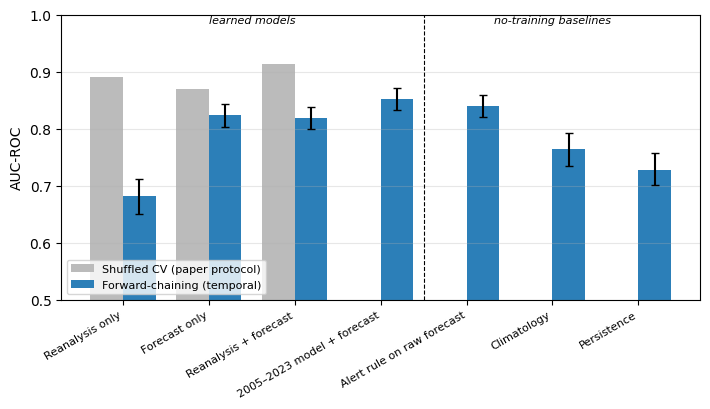

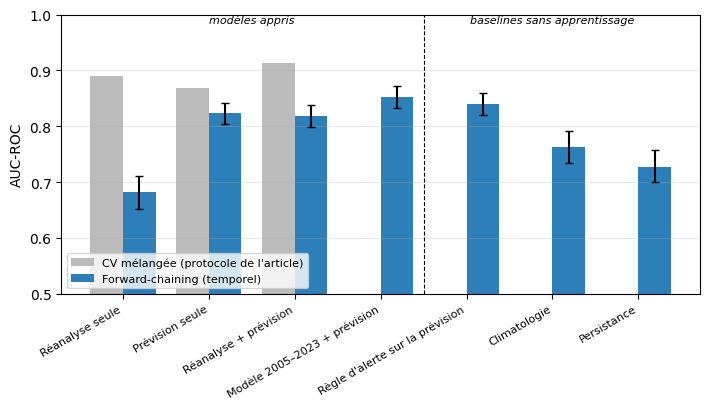

In [18]:
LAB = {
 "en": {"Réanalyse seule": "Reanalysis only", "Prévision seule": "Forecast only",
        "Réanalyse + Prévision": "Reanalysis + forecast", "Réanalyse + Prévision normalisée": "Reanalysis + normalized forecast",
        HIST: "2005–2023 reanalysis model", HIST_FC: "2005–2023 model + forecast",
        RULE: "Alert rule on raw forecast", "Prévision brute (cumul, mm)": "Raw forecast (mm)",
        "Climatologie": "Climatology", "Persistance": "Persistence",
        "t_a": "Shuffled CV (paper protocol)", "t_c": "Forward-chaining (temporal)",
        "y": "AUC-ROC", "title": "Forecast contribution: shuffled vs temporal validation",
        "learned": "learned models", "base": "no-training baselines"},
 "fr": {"Réanalyse seule": "Réanalyse seule", "Prévision seule": "Prévision seule",
        "Réanalyse + Prévision": "Réanalyse + prévision", "Réanalyse + Prévision normalisée": "Réanalyse + prévision normalisée",
        HIST: "Modèle réanalyse 2005–2023", HIST_FC: "Modèle 2005–2023 + prévision",
        RULE: "Règle d'alerte sur la prévision", "Prévision brute (cumul, mm)": "Prévision brute (mm)",
        "Climatologie": "Climatologie", "Persistance": "Persistance",
        "t_a": "CV mélangée (protocole de l'article)", "t_c": "Forward-chaining (temporel)",
        "y": "AUC-ROC", "title": "Apport de la prévision : validation mélangée vs temporelle",
        "learned": "modèles appris", "base": "baselines sans apprentissage"},
}
FIG_MODELS = ["Réanalyse seule", "Prévision seule", "Réanalyse + Prévision", HIST_FC,
              RULE, "Climatologie", "Persistance"]
a_map = resA.set_index("Modèle").AUC.to_dict()
a_map[RULE] = np.nan
for lang, L in LAB.items():
    fig, ax = plt.subplots(figsize=(7.2, 4.2))
    x = np.arange(len(FIG_MODELS)); w = 0.38
    va = [a_map.get(m, np.nan) for m in FIG_MODELS]
    vc = [resC.loc[m, "AUC_poolée"] for m in FIG_MODELS]
    err = np.array([[resC.loc[m, "AUC_poolée"] - resC.loc[m, "IC95_bas"] for m in FIG_MODELS],
                    [resC.loc[m, "IC95_haut"] - resC.loc[m, "AUC_poolée"] for m in FIG_MODELS]])
    ax.bar(x - w / 2, va, w, color="#BBBBBB", label=L["t_a"])
    ax.bar(x + w / 2, vc, w, yerr=err, capsize=3, color="#2C7FB8", label=L["t_c"])
    ax.axvline(3.5, color="k", lw=0.8, ls="--")
    ax.text(1.5, 0.985, L["learned"], ha="center", fontsize=8, style="italic")
    ax.text(5.0, 0.985, L["base"], ha="center", fontsize=8, style="italic")
    ax.set_xticks(x); ax.set_xticklabels([L[m] for m in FIG_MODELS], rotation=30, ha="right", fontsize=8)
    ax.set_ylim(0.5, 1.0); ax.set_ylabel(L["y"]); ax.grid(axis="y", alpha=0.3)
    ax.legend(fontsize=8, loc="lower left")
    plt.tight_layout()
    fig.savefig(OUT / f"fig_validation_temporelle_{lang}.png", dpi=200, bbox_inches="tight")
    plt.show()

## 12. Conclusions (exécution du 25/09/2026)

Données : 18 zones, 8 514 jours-zones de saison des pluies, 2024-06 → 2026-09-15 (3 saisons) ;
évaluation forward-chaining sur 7 416 jours-zones (août 2024 → sept. 2026). Contrôles : raccord
réanalyse 2025-07/08 sans saut notable (sauf un petit saut d'humidité du sol en surface,
0,007 m³/m³) ; pluie réalisée des prévisions = réanalyse (corr. 1,0) ; skill J+1 = 0,56 (vraie
prévision) ; anti-fuite vérifié.

**1. Le protocole de l'article surestime fortement.** CV mélangée : AUC 0,914 (reproduit), avec
100 % des dates de test présentes à l'entraînement. En forward-chaining, le même modèle
(RF réanalyse + prévision appris sur l'archive courte) tombe à **0,819 [0,799–0,838]**.

**2. Appris sur l'archive courte seule, le RF ne bat pas la baseline opérationnelle.** Appliquer la
règle d'alerte directement à la prévision donne 0,840 [0,821–0,859] ; écart RF − règle = −0,022
[−0,033 ; −0,010].

**3. Le meilleur modèle combine 19 ans d'historique et la prévision : AUC 0,852 [0,833–0,871].**
- gain dû à la prévision : **+0,061** [0,045–0,078] sur le modèle historique seul (0,791, cohérent
  avec les 0,80 de l'article) ;
- gain sur la règle appliquée à la prévision : **+0,012** [0,002–0,021], petit mais significatif ;
- meilleur PR-AUC (0,582 contre 0,550) et meilleure précision au seuil opérationnel (0,404 contre
  0,394 ; rappel 0,84 contre 0,87).

**4. Saisons.** Classement stable ; 2026 est plus difficile pour tous (≈ 0,76). Holdouts :
2024→2025 = 0,877, 2024+2025→2026 = 0,764 (meilleur modèle dans les deux cas). Le protocole B
(blocs purgés) confirme.

**5. Baselines.** La prévision numérique apporte l'essentiel (règle − climatologie = +0,077).
Le seuil opérationnel appris sur le passé n'atteint pas tout à fait les 90 % de rappel visés
(0,84–0,87) : dérive d'une saison à l'autre.

**6. Tambacounda, 14 août 2025.** Les trois modèles étaient en alerte **tous les jours du 8 au
16 août** : l'épisode était anticipé, mais l'alerte n'était pas spécifique au 14. La réanalyse
n'enregistre que **22 mm** ce jour-là, contre plus de 150 mm rapportés par OCHA : la résolution
(~11 km) lisse fortement les orages convectifs. Cela plaide pour des pluviomètres ou le radar, et
pour la couche citoyenne.

**7. Limites de la cible révélées.** (a) Les crues du fleuve (Matam, Bakel, Podor, septembre 2025)
viennent de l'amont et de Manantali : une cible de pluie locale ne peut pas les représenter.
(b) Les seuils P97/P95 sont calculés sur **tous les jours de l'année**, saison sèche comprise :
dans les zones arides, ils deviennent très bas (Podor : P97 = 3,0 mm/j, P95 sur 3 j = 5,9 mm),
donc une pluie modeste compte comme « risque ». C'est à signaler comme limite de l'article (ou à
corriger dans un travail futur : seuils sur la saison des pluies, ou plancher absolu en mm).

**Pour l'article (§V-B)** : remplacer « 0,888 → 0,913 » par « 0,791 → **0,852** en forward-chaining
sur trois saisons (2024–2026) », remplacer « 0,912 contre 0,874 » par « 0,852 contre 0,840 pour la
règle appliquée à la prévision brute (+0,012 [0,002–0,021]) », et ajouter la comparaison avec la CV
mélangée comme illustration méthodologique. Figure : `fig_validation_temporelle_en.png` / `_fr.png`.